<a href="https://colab.research.google.com/github/parveenummu75-blip/deep-learning/blob/main/neural_network_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Neural Network with 3 Inputs, 2 Hidden Layers, and 1 Output

This notebook demonstrates:
- Creating a simulated dataset with 3 input features and 1 output.  
- Building a simple neural network with:
  - **3 input nodes**
  - **2 hidden layers (2 nodes each)**
  - **1 output node**
- Training and making predictions.


In [ ]:
# Import NumPy for numerical computations and array operations
import numpy as np

# Import Pandas for loading and manipulating datasets
import pandas as pd

# Import train_test_split to divide the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import StandardScaler to normalize/standardize feature values
from sklearn.preprocessing import StandardScaler

# Import Sequential model to build a neural network layer by layer
from tensorflow.keras.models import Sequential

# Import Dense layer to create fully connected neural network layers
from tensorflow.keras.layers import Dense

# Import Matplotlib for plotting graphs and visualizing results
import matplotlib.pyplot as plt

In [ ]:
# Set a random seed so that the same random numbers are generated every time
np.random.seed(42)

# Define the total number of samples (data points)
n_samples = 200

# Generate a dataset with 200 samples and 3 input features
# Each feature value is a random number between 0 and 1
X = np.random.rand(n_samples, 3)

# Generate the target (output) values
# Weighted sum of the three features:
# Feature 1 -> 30% contribution
# Feature 2 -> 50% contribution
# Feature 3 -> 20% contribution
# Add small random noise to make the data more realistic
# If the final value is greater than 0.5, assign class True; otherwise False
y = (X[:,0]*0.3 + X[:,1]*0.5 + X[:,2]*0.2 +
     np.random.normal(0, 0.05, n_samples)) > 0.5

# Convert Boolean values (True/False) into integers (1/0)
y = y.astype(int)

# Display the dimensions of the input feature matrix
print("Input shape:", X.shape)

# Display the dimensions of the output vector
print("Output shape:", y.shape)

Input shape: (200, 3)
Output shape: (200,)


In [ ]:
# Split the dataset into training and testing sets
# 80% of the data is used for training and 20% for testing
# random_state=42 ensures the same split every time the code is executed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create an object of StandardScaler to standardize the feature values
scaler = StandardScaler()

# Compute the mean and standard deviation from the training data
# Then transform the training data so that each feature has:
# Mean = 0 and Standard Deviation = 1
X_train = scaler.fit_transform(X_train)

# Use the same mean and standard deviation obtained from the training data
# to standardize the test data
X_test = scaler.transform(X_test)

In [3]:

# Build a Sequential Neural Network
# The layers are added one after another
model = Sequential([

    # First Hidden Layer
    # Dense(2) -> 2 neurons in this hidden layer
    # input_dim=3 -> The network receives 3 input features
    # activation='relu' -> Uses the ReLU activation function
    Dense(2, input_dim=3, activation='relu'),

    # Second Hidden Layer
    # Dense(2) -> 2 neurons
    # activation='relu' -> Applies the ReLU activation function
    Dense(2, activation='relu'),

    # Output Layer
    # Dense(1) -> One output neuron for binary classification
    # activation='relu' -> ReLU activation function
    # (Note: For binary classification, 'sigmoid' is usually preferred.)
    Dense(1, activation='relu')
])

# Compile the neural network
# optimizer='adam' -> Adam optimizer updates the weights efficiently
# loss='binary_crossentropy' -> Loss function for binary classification
# metrics=['accuracy'] -> Display classification accuracy during training
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display the architecture of the neural network
# It shows the layers, output shapes, and number of trainable parameters
model.summary()


NameError: name 'Sequential' is not defined

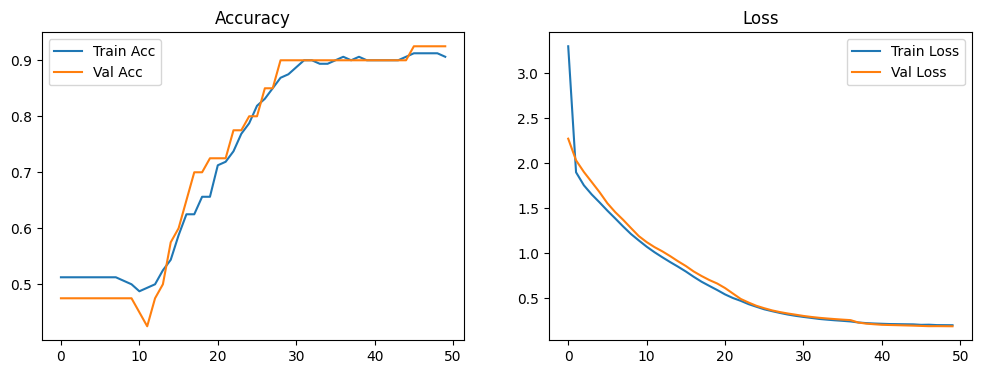

In [ ]:

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=0, validation_data=(X_test, y_test))

# Plot accuracy and loss
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()


In [ ]:

# Make predictions
y_pred = (model.predict(X_test) > 0.5).astype(int)

print("Sample Predictions:")
print("True labels:     ", y_test[:10])
print("Predicted labels:", y_pred[:10].ravel())


1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Sample Predictions:
True labels:      [0 0 1 1 1 0 0 1 1 0]
Predicted labels: [0 0 1 1 1 0 0 1 1 1]


In [4]:
# Exercise 10 – Multi-Layer Perceptron for XOR

from sklearn.neural_network import MLPClassifier
import numpy as np

# XOR Input
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR Output
y = np.array([0, 1, 1, 0])

# Create MLP Model
# hidden_layer_sizes=(2,) means one hidden layer with two neurons
mlp = MLPClassifier(
    hidden_layer_sizes=(2,),
    activation='logistic',      # Sigmoid activation
    solver='lbfgs',
    max_iter=5000,
    random_state=42
)

# Train the model
mlp.fit(X, y)

# Predict outputs
predictions = mlp.predict(X)

# Display Results
print("XOR Gate using Multi-Layer Perceptron")
print("-------------------------------------")

for i in range(len(X)):
    print(f"Input: {X[i]}  Expected: {y[i]}  Predicted: {predictions[i]}")

XOR Gate using Multi-Layer Perceptron
-------------------------------------
Input: [0 0]  Expected: 0  Predicted: 1
Input: [0 1]  Expected: 1  Predicted: 1
Input: [1 0]  Expected: 1  Predicted: 1
Input: [1 1]  Expected: 0  Predicted: 0


In [5]:
# Exercise – Compare Hidden Neurons in MLP

import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# XOR Dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

# Duplicate data for training and validation
X = np.tile(X, (100, 1))
y = np.tile(y, 100)

# Split dataset
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Hidden neurons to test
neurons = [2, 4, 8, 16]

print("=" * 65)
print("{:<10} {:<20} {:<20} {:<10}".format(
    "Neurons", "Training Accuracy", "Validation Accuracy", "Loss"))
print("=" * 65)

for n in neurons:

    model = MLPClassifier(
        hidden_layer_sizes=(n,),
        activation='logistic',
        solver='adam',
        learning_rate_init=0.01,
        max_iter=5000,
        random_state=42
    )

    # Train
    model.fit(X_train, y_train)

    # Predict
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    # Accuracy
    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    # Loss
    loss = model.loss_

    print("{:<10} {:<20.4f} {:<20.4f} {:.6f}".format(
        n, train_acc, val_acc, loss))

Neurons    Training Accuracy    Validation Accuracy  Loss      
2          0.5219               0.4125               0.691175
4          0.5219               0.4125               0.691072
8          1.0000               1.0000               0.016214
16         1.0000               1.0000               0.010960


In [6]:
# Exercise – Compare Activation Functions in MLP

import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# XOR Dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

# Duplicate dataset for training and validation
X = np.tile(X, (100, 1))
y = np.tile(y, 100)

# Split the dataset
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Activation functions to compare
activations = {
    "ReLU": "relu",
    "Sigmoid": "logistic",
    "Tanh": "tanh"
}

print("=" * 75)
print("{:<12} {:<20} {:<20} {:<10}".format(
    "Activation", "Training Accuracy", "Validation Accuracy", "Loss"))
print("=" * 75)

for name, act in activations.items():

    model = MLPClassifier(
        hidden_layer_sizes=(8,),     # Same network with 8 hidden neurons
        activation=act,
        solver='adam',
        learning_rate_init=0.01,
        max_iter=5000,
        random_state=42
    )

    # Train the model
    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    # Accuracy
    train_acc = accuracy_score(y_train, train_pred)
    val_acc = accuracy_score(y_val, val_pred)

    # Loss
    loss = model.loss_

    print("{:<12} {:<20.4f} {:<20.4f} {:.6f}".format(
        name, train_acc, val_acc, loss))

Activation   Training Accuracy    Validation Accuracy  Loss      
ReLU         1.0000               1.0000               0.012445
Sigmoid      1.0000               1.0000               0.016214
Tanh         1.0000               1.0000               0.008713


Epochs     Train Accuracy       Test Accuracy        Loss      
10         0.2437               0.2750               0.671044
30         1.0000               1.0000               0.563379
50         1.0000               1.0000               0.426789
100        1.0000               1.0000               0.113523


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


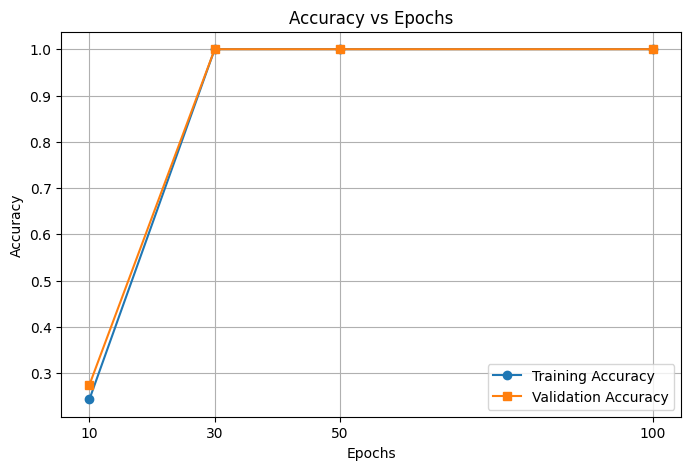

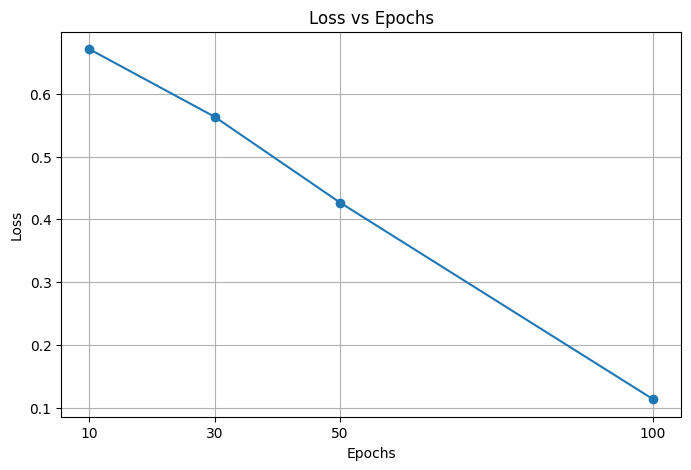


Best Model
----------
Best Epochs : 30
Validation Accuracy : 1.0
Loss : 0.5633791348427148


In [7]:
# Exercise – Compare Different Epochs in MLP

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# XOR Dataset
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

y = np.array([0, 1, 1, 0])

# Duplicate dataset
X = np.tile(X, (100, 1))
y = np.tile(y, 100)

# Split into Train and Test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Epoch values
epochs = [10, 30, 50, 100]

train_accuracy = []
test_accuracy = []
loss_values = []

print("=" * 70)
print("{:<10} {:<20} {:<20} {:<10}".format(
    "Epochs", "Train Accuracy", "Test Accuracy", "Loss"))
print("=" * 70)

for epoch in epochs:

    model = MLPClassifier(
        hidden_layer_sizes=(8,),
        activation='relu',
        solver='adam',
        max_iter=epoch,
        learning_rate_init=0.01,
        random_state=42
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    loss = model.loss_

    train_accuracy.append(train_acc)
    test_accuracy.append(test_acc)
    loss_values.append(loss)

    print("{:<10} {:<20.4f} {:<20.4f} {:.6f}".format(
        epoch, train_acc, test_acc, loss))

# ---------------- Accuracy Graph ----------------
plt.figure(figsize=(8,5))
plt.plot(epochs, train_accuracy, marker='o', label='Training Accuracy')
plt.plot(epochs, test_accuracy, marker='s', label='Validation Accuracy')
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.xticks(epochs)
plt.grid(True)
plt.legend()
plt.show()

# ---------------- Loss Graph ----------------
plt.figure(figsize=(8,5))
plt.plot(epochs, loss_values, marker='o')
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.grid(True)
plt.show()

# ---------------- Best Model ----------------
best_epoch = epochs[np.argmax(test_accuracy)]

print("\nBest Model")
print("----------")
print("Best Epochs :", best_epoch)
print("Validation Accuracy :", max(test_accuracy))
print("Loss :", loss_values[np.argmax(test_accuracy)])

In [8]:
# Exercise – Compare Single Hidden Layer vs Two Hidden Layers

import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# XOR Dataset
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])

y = np.array([0,1,1,0])

# Duplicate dataset
X = np.tile(X, (100,1))
y = np.tile(y, 100)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# ---------------- Model 1 ----------------
print("\nModel 1: Input → Hidden → Output")

model1 = Sequential()

model1.add(Dense(8, input_dim=2, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))

model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train,
    epochs=100,
    verbose=0,
    validation_data=(X_test, y_test)
)

train_loss1, train_acc1 = model1.evaluate(X_train, y_train, verbose=0)
test_loss1, test_acc1 = model1.evaluate(X_test, y_test, verbose=0)

# ---------------- Model 2 ----------------
print("\nModel 2: Input → Hidden1 → Hidden2 → Output")

model2 = Sequential()

model2.add(Dense(8, input_dim=2, activation='relu'))
model2.add(Dense(8, activation='relu'))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train,
    epochs=100,
    verbose=0,
    validation_data=(X_test, y_test)
)

train_loss2, train_acc2 = model2.evaluate(X_train, y_train, verbose=0)
test_loss2, test_acc2 = model2.evaluate(X_test, y_test, verbose=0)

# ---------------- Results ----------------
print("\nComparison Table")
print("=" * 70)
print("{:<25} {:<15} {:<15} {:<10}".format(
    "Model",
    "Train Acc",
    "Validation Acc",
    "Loss"))
print("=" * 70)

print("{:<25} {:<15.4f} {:<15.4f} {:.6f}".format(
    "Input-Hidden-Output",
    train_acc1,
    test_acc1,
    test_loss1))

print("{:<25} {:<15.4f} {:<15.4f} {:.6f}".format(
    "Input-Hidden1-Hidden2-Output",
    train_acc2,
    test_acc2,
    test_loss2))

# ---------------- Best Model ----------------
if test_acc2 > test_acc1:
    print("\nBest Model : Input → Hidden1 → Hidden2 → Output")
elif test_acc1 > test_acc2:
    print("\nBest Model : Input → Hidden → Output")
else:
    print("\nBoth models perform similarly.")


Model 1: Input → Hidden → Output


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model 2: Input → Hidden1 → Hidden2 → Output

Comparison Table
Model                     Train Acc       Validation Acc  Loss      
Input-Hidden-Output       1.0000          1.0000          0.286503
Input-Hidden1-Hidden2-Output 1.0000          1.0000          0.015911

Both models perform similarly.


In [9]:
# Exercise – Generate Your Own Dataset and Train Neural Network

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# -----------------------------
# Step 1: Generate Dataset
# -----------------------------
np.random.seed(42)

# 300 samples with 3 input features
X = np.random.rand(300, 3)

# Generate binary target
# Class = 1 if sum of features > 1.5 else 0
y = (X[:,0] + X[:,1] + X[:,2] > 1.5).astype(int)

# -----------------------------
# Step 2: Split Dataset
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# -----------------------------
# Step 3: Normalize Features
# -----------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Step 4: Build Neural Network
# -----------------------------
model = Sequential()

model.add(Dense(8, input_dim=3, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# -----------------------------
# Step 5: Compile Model
# -----------------------------
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Step 6: Train Model
# -----------------------------
model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    verbose=1
)

# -----------------------------
# Step 7: Evaluate Model
# -----------------------------
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nModel Evaluation")
print("----------------")
print("Test Accuracy : {:.2f}%".format(accuracy * 100))
print("Loss          : {:.4f}".format(loss))

# -----------------------------
# Step 8: Predict
# -----------------------------
predictions = (model.predict(X_test) > 0.5).astype(int)

print("\nFirst 10 Predictions")
print("--------------------")
for i in range(10):
    print("Actual:", y_test[i], " Predicted:", predictions[i][0])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6042 - loss: 0.6955
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6625 - loss: 0.6733
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7333 - loss: 0.6525 
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7542 - loss: 0.6310
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7833 - loss: 0.6088
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7958 - loss: 0.5856
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8125 - loss: 0.5605 
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8417 - loss: 0.5335 
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8667 - loss: 0.5056
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8792 - loss: 0.4758 
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9042 - loss: 0.4447 
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.93